# Load Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
from pathlib import Path

# make pygenelab importable from this folder
PYGENELAB_PARENT = Path("/ix/djishnu/Akanksha/analysis_code/snRNA_TA_muscle_analysis/TA_muscle_code/py_scripts")
if str(PYGENELAB_PARENT) not in sys.path:
    sys.path.insert(0, str(PYGENELAB_PARENT))

# auto-reload pygenelab when its .py files change (no need to restart the kernel)
%load_ext autoreload
%autoreload 2

import pygenelab as pgl
import scanpy as sc
import decoupler as dc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from pathlib import Path
from scipy import sparse
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Util Functions

In [4]:
def get_dense_matrix(X):
    """
    convert sparse matrix to dense numpy array
    """

    # get_dense_matrix
    # api:
    # get_dense_matrix(
    #     X=adata.X,
    # )

    if sparse.issparse(X):
        return X.toarray()

    return np.asarray(X)

In [5]:
def get_low_cv_genes(
    X,
    gene_names,
    n_bins=10,
    bottom_frac=0.10
):
    """
    select low-cv genes from expression matrix
    """

    # get_low_cv_genes
    # api:
    # get_low_cv_genes(
    #     X=X,
    #     gene_names=adata.var_names,
    #     n_bins=10,
    #     bottom_frac=0.10,
    # )

    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=1)

    cv = stds / (means + 1e-12)

    valid = np.isfinite(cv) & np.isfinite(means) & (means > 0)
    valid_idx = np.where(valid)[0]

    if len(valid_idx) == 0:
        return []

    mean_series = pd.Series(means[valid_idx], index=valid_idx)

    bins = pd.qcut(
        mean_series,
        q=n_bins,
        labels=False,
        duplicates="drop"
    )

    selected_idx = []

    for bin_id in sorted(bins.dropna().unique()):
        genes_in_bin = bins.index[bins == bin_id].to_numpy()

        if len(genes_in_bin) == 0:
            continue

        n_select = max(1, int(np.ceil(len(genes_in_bin) * bottom_frac)))

        bin_cv = cv[genes_in_bin]
        low_cv_idx = genes_in_bin[np.argsort(bin_cv)[:n_select]]

        selected_idx.extend(low_cv_idx)

    selected_idx = sorted(set(selected_idx))
    selected_genes = gene_names[selected_idx].tolist()

    return selected_genes


In [6]:
def calculate_noise_one_celltype(
    adata_ct,
    condition_col="condition",
    group1="WT",
    group2="KO",
    layer=None,
    max_cells=300,
    min_cells=10,
    n_bins=10,
    bottom_frac=0.10,
    random_state=1
):
    """
    calculate transcriptional noise for one cell type
    """

    # calculate_noise_one_celltype
    # api:
    # noise_df, summary = calculate_noise_one_celltype(
    #     adata_ct=adata_ct,
    #     condition_col="condition",
    #     group1="WT",
    #     group2="KO",
    #     layer=None,
    # )

    rng = np.random.default_rng(random_state)

    # get cells from each condition
    group1_cells = adata_ct.obs_names[
        adata_ct.obs[condition_col] == group1
    ].to_numpy()

    group2_cells = adata_ct.obs_names[
        adata_ct.obs[condition_col] == group2
    ].to_numpy()

    # sample equal number of cells
    n_sample = min(len(group1_cells), len(group2_cells), max_cells)

    if n_sample < min_cells:
        summary = {
            "status": "skipped",
            "reason": "not enough cells",
            f"n_{group1}_available": len(group1_cells),
            f"n_{group2}_available": len(group2_cells)
        }

        return None, summary

    group1_sample = rng.choice(
        group1_cells,
        size=n_sample,
        replace=False
    )

    group2_sample = rng.choice(
        group2_cells,
        size=n_sample,
        replace=False
    )

    selected_cells = np.concatenate([group1_sample, group2_sample])
    adata_sub = adata_ct[selected_cells, :].copy()

    # get normalized expression matrix
    if layer is None:
        X = get_dense_matrix(adata_sub.X).astype(float)
    else:
        X = get_dense_matrix(adata_sub.layers[layer]).astype(float)

    # select low-cv genes
    low_cv_genes = get_low_cv_genes(
        X=X,
        gene_names=adata_sub.var_names,
        n_bins=n_bins,
        bottom_frac=bottom_frac
    )

    if len(low_cv_genes) == 0:
        summary = {
            "status": "skipped",
            "reason": "no low-cv genes found",
            f"n_{group1}_available": len(group1_cells),
            f"n_{group2}_available": len(group2_cells)
        }

        return None, summary

    # subset to low-cv genes
    gene_idx = adata_sub.var_names.get_indexer(low_cv_genes)
    X_lowcv = X[:, gene_idx]

    labels = adata_sub.obs[condition_col].to_numpy()
    cell_ids = adata_sub.obs_names.to_numpy()

    # split expression by condition
    X_group1 = X_lowcv[labels == group1]
    X_group2 = X_lowcv[labels == group2]

    ids_group1 = cell_ids[labels == group1]
    ids_group2 = cell_ids[labels == group2]

    # calculate average profile for each group
    mean_group1 = X_group1.mean(axis=0)
    mean_group2 = X_group2.mean(axis=0)

    # calculate euclidean distance from own group average
    noise_group1 = np.linalg.norm(X_group1 - mean_group1, axis=1)
    noise_group2 = np.linalg.norm(X_group2 - mean_group2, axis=1)

    # save per-cell results
    noise_df = pd.DataFrame({
        "cell_id": np.concatenate([ids_group1, ids_group2]),
        "condition": [group1] * len(noise_group1) + [group2] * len(noise_group2),
        "noise": np.concatenate([noise_group1, noise_group2])
    })

    # compare noise distributions
    pval = mannwhitneyu(
        noise_group1,
        noise_group2,
        alternative="two-sided"
    ).pvalue

    mean_noise_group1 = noise_group1.mean()
    mean_noise_group2 = noise_group2.mean()

    log2_ratio = np.log2(
        (mean_noise_group2 + 1e-12) / 
        (mean_noise_group1 + 1e-12)
    )

    summary = {
        "status": "done",
        f"n_{group1}": n_sample,
        f"n_{group2}": n_sample,
        f"mean_noise_{group1}": mean_noise_group1,
        f"mean_noise_{group2}": mean_noise_group2,
        f"log2_{group2}_over_{group1}": log2_ratio,
        "pval": pval,
        "n_low_cv_genes": len(low_cv_genes)
    }

    return noise_df, summary

In [7]:
def plot_transcriptional_noise(
    noise_all_df,
    celltype_col="celltype",
    condition_col="condition",
    noise_col="noise",
    celltype_order=None,
    group_order=("WT", "KO"),
    figsize=(14, 5),
    title="WT vs KO Transcriptional Noise",
    bar_width=0.5,
    bar_step=0.6
):
    """
    plot transcriptional noise boxplot
    """

    # plot_transcriptional_noise
    # api:
    # fig, ax = plot_transcriptional_noise(
    #     noise_all_df=noise_all_df,
    #     celltype_col="celltype",
    #     condition_col="condition",
    #     noise_col="noise",
    # )

    if celltype_order is None:
        celltype_order = noise_all_df[celltype_col].dropna().unique().tolist()

    plot_data = [
        noise_all_df[
            (noise_all_df[celltype_col] == celltype) &
            (noise_all_df[condition_col] == group)
        ][noise_col].dropna().values
        for celltype in celltype_order
        for group in group_order
    ]

    # uniform spacing: every adjacent bar is bar_step apart (no extra gap between celltype pairs)
    n_groups = len(group_order)
    positions = []
    labels = []

    pos = 1.0
    for celltype in celltype_order:
        positions.extend([pos + i * bar_step for i in range(n_groups)])
        labels.append(celltype)
        pos += n_groups * bar_step

    fig, ax = plt.subplots(figsize=figsize)

    bp = ax.boxplot(
        plot_data,
        positions=positions,
        widths=bar_width,
        patch_artist=True,
        showfliers=False
    )

    colors = {
        group_order[0]: "#50BA47",
        group_order[1]: "#A15DBA"
    }

    for i, box in enumerate(bp["boxes"]):
        group = group_order[i % len(group_order)]
        box.set_facecolor(colors[group])
        box.set_alpha(0.8)

    # set x-axis labels at the center of each celltype's group
    tick_positions = [
        np.mean(positions[i:i + n_groups])
        for i in range(0, len(positions), n_groups)
    ]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(celltype_order, rotation=90)

    ax.set_ylabel("Transcriptional noise")
    ax.set_xlabel("Cell type")
    ax.set_title(title)

    # add legend
    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            color=colors[group],
            lw=8,
            label=group
        )
        for group in group_order
    ]

    ax.legend(
        handles=legend_handles,
        title=condition_col,
        frameon=False
    )

    plt.tight_layout()

    return fig, ax

# Load Dataset

In [8]:
UPDATED_MICE_DATASET_PATH = "/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/adata_harmony_v2_re_annot.h5ad"
adata = sc.read_h5ad(UPDATED_MICE_DATASET_PATH)

In [9]:
# columns to use
celltype_col = "re_annot"
condition_col = "condition"

# groups to compare
group1 = "WT"
group2 = "KO"

layer = None

In [10]:
cell_types = adata.obs["re_annot"].unique().to_list()
cell_types

['Fast IIX',
 'Fast IIB',
 'NMJ',
 'Fast IIA',
 'MTJ-IIA',
 'FAPs',
 'Pericyte',
 'MTJ-IIX',
 'MTJ-IIB',
 'Macrophages',
 'EC',
 'Skeleton MuSc',
 'Tendon']

In [11]:
SEX = None
if SEX == "F" or SEX == "M":
    adata = pgl.subset_adata_by_obs(adata, filters={"sex": SEX})
adata.obs["sex"].value_counts()

sex
M    44171
F    42470
Name: count, dtype: int64

# Calculate Transcriptional Noise

In [12]:
all_noise = []
all_summary = []

for celltype in cell_types:
    print(f"processing: {celltype}")

    # subset one cell type
    adata_ct = adata[
        adata.obs[celltype_col] == celltype
    ].copy()

    # calculate noise
    noise_df, summary = calculate_noise_one_celltype(
        adata_ct=adata_ct,
        condition_col=condition_col,
        group1=group1,
        group2=group2,
        layer=layer,
        max_cells=300,
        min_cells=10,
        n_bins=10,
        bottom_frac=0.10,
        random_state=1
    )

    # store summary
    summary["celltype"] = celltype
    all_summary.append(summary)

    # store per-cell noise values
    if noise_df is not None:
        noise_df["celltype"] = celltype
        all_noise.append(noise_df)

# combine results
noise_all_df = pd.concat(all_noise, ignore_index=True)
summary_df = pd.DataFrame(all_summary)

# adjust p-values
done_mask = summary_df["status"] == "done"

summary_df.loc[done_mask, "padj"] = multipletests(
    summary_df.loc[done_mask, "pval"],
    method="fdr_bh"
)[1]

summary_df["significant"] = summary_df["padj"] < 0.05

# sort summary
summary_df = summary_df.sort_values(
    f"log2_{group2}_over_{group1}",
    ascending=False,
    na_position="last"
)

summary_df

processing: Fast IIX
processing: Fast IIB
processing: NMJ
processing: Fast IIA
processing: MTJ-IIA
processing: FAPs
processing: Pericyte
processing: MTJ-IIX
processing: MTJ-IIB
processing: Macrophages
processing: EC
processing: Skeleton MuSc
processing: Tendon


,status,n_WT,n_KO,mean_noise_WT,mean_noise_KO,log2_KO_over_WT,pval,n_low_cv_genes,celltype,padj,significant
0,done,300,300,8.509889,8.704338,0.032594,0.146531,190,Fast IIX,0.476225,False
12,done,300,300,12.421274,12.647071,0.025990,0.098808,250,Tendon,0.428166,False
11,done,300,300,12.643783,12.767850,0.014087,0.237017,230,Skeleton MuSc,0.500062,False
7,done,300,300,8.780923,8.866408,0.013977,0.189042,210,MTJ-IIX,0.491510,False
4,done,192,192,9.057270,9.140794,0.013243,0.432567,190,MTJ-IIA,0.624819,False
2,done,300,300,9.609547,9.620665,0.001668,0.775132,220,NMJ,0.834163,False
3,done,300,300,8.892499,8.899188,0.001085,0.666314,199,Fast IIA,0.787463,False
6,done,300,300,13.607259,13.591598,-0.001661,0.834163,230,Pericyte,0.834163,False
5,done,300,300,14.605543,14.539776,-0.006511,0.269264,240,FAPs,0.500062,False
10,done,300,300,13.751928,13.656057,-0.010093,0.510990,220,EC,0.664287,False


# Plot

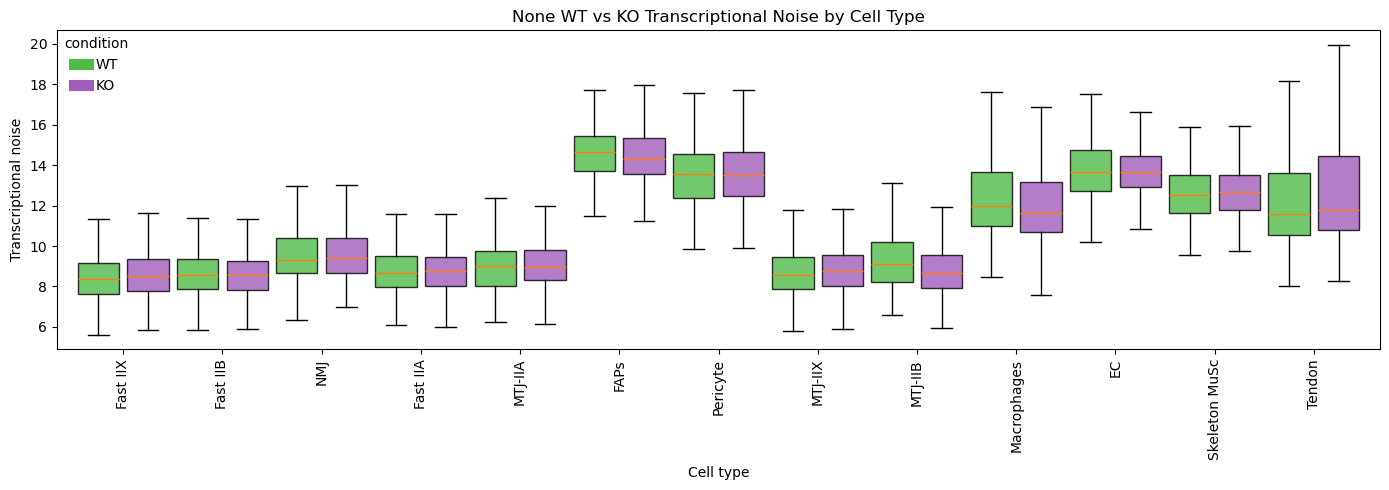

In [13]:
fig, ax = plot_transcriptional_noise(
    noise_all_df=noise_all_df,
    celltype_col="celltype",
    condition_col="condition",
    noise_col="noise",
    celltype_order=cell_types,
    group_order=(group1, group2),
    figsize=(14, 5),
    title=f"{SEX} WT vs KO Transcriptional Noise by Cell Type"
)

plt.show()

# Save Plot

In [ ]:
output_dir = Path("Output")
output_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
# save plot
png_path = output_dir / f"{SEX}_WT_vs_KO_Transcriptional_Noise_PNG.png"
svg_path = output_dir / f"{SEX}_WT_vs_KO_Transcriptional_Noise_SVG.svg"

pgl.save_fig_as_png(fig, png_path)
pgl.save_editable_svg(fig, svg_path)

In [ ]:
# save stats
stats_df = summary_df[["celltype", "n_WT", "n_KO", "n_low_cv_genes", "mean_noise_WT", "mean_noise_KO", "log2_KO_over_WT"]]

stats_png_path = output_dir / f"{SEX}_WT_vs_KO_Transcriptional_Noise_Stats_PNG.png"
stats_svg_path = output_dir / f"{SEX}_WT_vs_KO_Transcriptional_Noise_Stats_SVG.svg"

stats_fig = pgl.save_df_table_image(stats_df)

pgl.save_fig_as_png(stats_fig, stats_png_path)
pgl.save_editable_svg(stats_fig, stats_svg_path)